# Multi-Task CNN for CIFAR-100: Fine & Coarse Classification

This notebook implements a custom **multi-task Convolutional Neural Network (CNN)** using PyTorch trained on the **CIFAR-100** dataset.

### Goals
- Simultaneously predict **100 fine-grained classes** and **20 coarse superclasses**
- Use a shared backbone with **two task-specific classification heads**
- Evaluate performance on both tasks independently

### Architecture Overview
```
Input (3×32×32)
     │
┌────▼────────────────────┐
│   Shared CNN Backbone   │  (3 convolutional blocks)
└────┬────────────────────┘
     │
┌────▼────┐    ┌────────────┐
│ Fine    │    │  Coarse    │
│ Head    │    │  Head      │
│(100 cls)│    │ (20 cls)   │
└─────────┘    └────────────┘
```

### No Data Augmentation — raw pixel values only (normalized).

## 1. Environment Setup

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torch.utils.data import random_split

import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

import time
import warnings
warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ── Device ───────────────────────────────────────────────────────────────────
DEVICE = (
    'cuda'  if torch.cuda.is_available()  else
    'mps'   if torch.backends.mps.is_available() else
    'cpu'
)
print(f'PyTorch  : {torch.__version__}')
print(f'Device   : {DEVICE}')
print(f'Torchvision: {torchvision.__version__}')

PyTorch  : 2.10.0+cu128
Device   : cuda
Torchvision: 0.25.0+cu128


## 2. Hyperparameters

In [2]:
# ── Training ─────────────────────────────────────────────────────────────────
BATCH_SIZE   = 128
NUM_EPOCHS   = 40
LEARNING_RATE = 1e-2
WEIGHT_DECAY  = 1e-4
DROPOUT = .25
LABEL_SMOOTHING = .4
COLOR_JITTER = .2

# -- Layer Dimensions ---------------------------------------------------------
CONV_CHANNEL_1 = 64
CONV_CHANNEL_2 = 128
CONV_CHANNEL_3 = 256
FC_FINE = 256
FC_FINE_2 = FC_FINE // 2
FC_COARSE = 128
FC_COARSE_2 = FC_COARSE // 2

# ── Loss weighting ───────────────────────────────────────────────────────────
# Combined loss = λ_fine * L_fine + λ_coarse * L_coarse
LAMBDA_FINE   = 1
LAMBDA_COARSE = .75

# ── Dataset ──────────────────────────────────────────────────────────────────
NUM_FINE_CLASSES   = 100
NUM_COARSE_CLASSES = 20
DATA_DIR = './data'

print('Hyperparameters loaded.')

Hyperparameters loaded.


## 3. CIFAR-100 Dataset

CIFAR-100 provides two label types per sample:
- **`fine_label`** — one of 100 specific classes (e.g. *apple*, *boy*, *dolphin*)
- **`coarse_label`** — one of 20 superclasses (e.g. *fruit & vegetables*, *people*, *large natural outdoor scenes*)

We create a custom `Dataset` wrapper to expose both label types simultaneously.

In [3]:
# ── CIFAR-100 coarse label names (official order) ─────────────────────────
COARSE_LABELS = [
    'aquatic mammals', 'fish', 'flowers', 'food containers',
    'fruit & vegetables', 'household electrical devices',
    'household furniture', 'insects', 'large carnivores',
    'large man-made outdoor things', 'large natural outdoor scenes',
    'large omnivores & herbivores', 'medium-sized mammals',
    'non-insect invertebrates', 'people', 'reptiles',
    'small mammals', 'trees', 'vehicles 1', 'vehicles 2'
]

# ── Minimal transform: resize to tensor + normalize ──────────────────────────
# CIFAR-100 stats (computed on training split)
CIFAR100_MEAN = (0.5071, 0.4867, 0.4408)
CIFAR100_STD  = (0.2675, 0.2565, 0.2761)

data_augment = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(brightness=COLOR_JITTER, contrast=COLOR_JITTER, saturation=COLOR_JITTER),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
])

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
])


class CIFAR100MultiTask(torch.utils.data.Dataset):
    """Wraps torchvision CIFAR100 to return (image, fine_label, coarse_label)."""

    def __init__(self, root, train=True, transform=None, download=True):
        self.base = torchvision.datasets.CIFAR100(
            root=root, train=train, transform=transform, download=download
        )
        # torchvision stores coarse labels inside the raw loaded data
        import pickle, os
        split = 'train' if train else 'test'
        path  = os.path.join(root, 'cifar-100-python', split)
        with open(path, 'rb') as f:
            d = pickle.load(f, encoding='bytes')
        self.coarse_labels = d[b'coarse_labels']

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        img, fine = self.base[idx]
        coarse    = self.coarse_labels[idx]
        return img, fine, coarse


# ── Instantiate datasets ──────────────────────────────────────────────────────
full_train_dataset = CIFAR100MultiTask(root=DATA_DIR, train=True,  transform=data_augment) # Adjust data augmentation here
test_dataset  = CIFAR100MultiTask(root=DATA_DIR, train=False, transform=transform)
VAL_SIZE   = 10_000
TRAIN_SIZE = len(full_train_dataset) - VAL_SIZE  # 40,000

train_dataset, val_dataset = random_split(full_train_dataset, [TRAIN_SIZE, VAL_SIZE], generator=torch.Generator().manual_seed(SEED))
val_dataset.dataset = CIFAR100MultiTask(root=DATA_DIR, train=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'Training samples : {len(train_dataset):,}')
print(f'Test samples     : {len(test_dataset):,}')
print(f'Batches per epoch: {len(train_loader):,}')
print(f'Fine classes     : {NUM_FINE_CLASSES}')
print(f'Coarse classes   : {NUM_COARSE_CLASSES}')

100%|██████████| 169M/169M [00:04<00:00, 35.9MB/s]


Training samples : 40,000
Test samples     : 10,000
Batches per epoch: 313
Fine classes     : 100
Coarse classes   : 20


### 3.1 Sample Visualisation

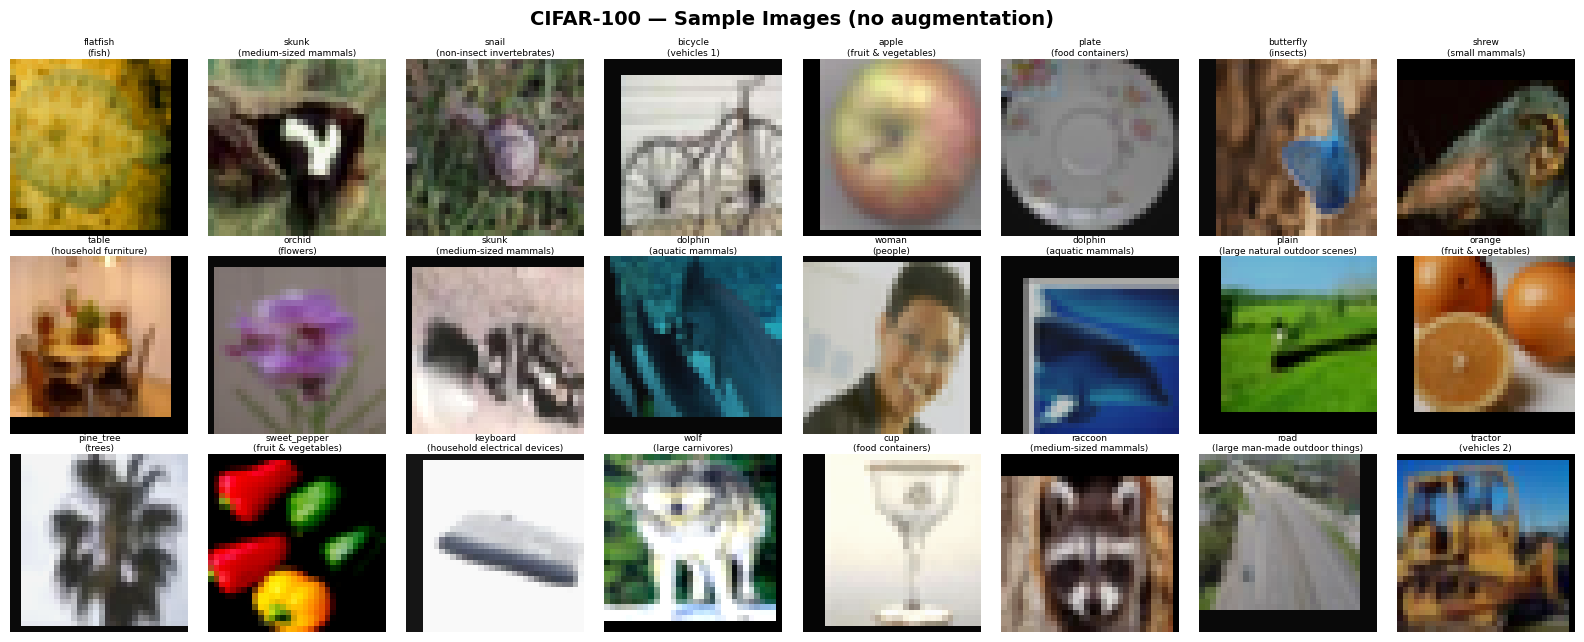

In [4]:
fine_names   = full_train_dataset.base.classes  # 100 class names

# Un-normalise helper
def unnorm(img_t, mean=CIFAR100_MEAN, std=CIFAR100_STD):
    img = img_t.clone()
    for c, (m, s) in enumerate(zip(mean, std)):
        img[c] = img[c] * s + m
    return img.permute(1, 2, 0).numpy().clip(0, 1)

fig, axes = plt.subplots(3, 8, figsize=(16, 6.5))
fig.suptitle('CIFAR-100 — Sample Images (no augmentation)', fontsize=14, fontweight='bold')
for ax, (img, fine, coarse) in zip(axes.flat,
        [train_dataset[i] for i in range(24)]):
    ax.imshow(unnorm(img))
    ax.set_title(f'{fine_names[fine]}\n({COARSE_LABELS[coarse]})',
                 fontsize=6.5, pad=2)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 4. Model Architecture

### Design Choices
| Component | Details |
|-----------|--------|
| **Backbone** | 3 convolutional blocks, each with `Conv→BN→ReLU→Conv→BN→ReLU→MaxPool` |
| **Channels** | 64 → 128 → 256 |
| **Regularisation** | Batch Normalisation + Dropout (p=0.4) |
| **Fine head** | FC(256×4×4 → 512) → ReLU → Dropout → FC(512 → 100) |
| **Coarse head** | FC(256×4×4 → 256) → ReLU → Dropout → FC(256 → 20) |

In [5]:
class ConvBlock(nn.Module):
    """Two Conv-BN-ReLU layers followed by MaxPool."""

    def __init__(self, in_ch, out_ch, pool=True, residual=True):
        super().__init__()
        self.residual = residual

        layers = [
            nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if pool:
            layers.append(nn.MaxPool2d(2, 2))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)



class MultiTaskCNN(nn.Module):
    """
    Shared CNN backbone with two classification heads:
      - fine_head   → 100 CIFAR-100 fine classes
      - coarse_head → 20 CIFAR-100 coarse superclasses
    """

    def __init__(self, num_fine=100, num_coarse=20, drop_p=DROPOUT):
        super().__init__()

        # ── Shared backbone ───────────────────────────────────────────────────
        # Input: 3×32×32
        self.block1 = ConvBlock(3,   CONV_CHANNEL_1)
        self.block2 = ConvBlock(CONV_CHANNEL_1, CONV_CHANNEL_2)
        self.block3 = ConvBlock(CONV_CHANNEL_2, CONV_CHANNEL_3)

        self.pool_flat = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),                  # → 256*4*4 = 4096
        )

        flat_dim = CONV_CHANNEL_3 * 4 * 4  # 4096

        # ── Fine-class head (100 classes) ─────────────────────────────────────
        self.fine_head = nn.Sequential(
            nn.Linear(flat_dim, FC_FINE),
            nn.BatchNorm1d(FC_FINE),
            nn.ReLU(inplace=True),
            nn.Dropout(drop_p),
            nn.Linear(FC_FINE, num_fine),
        )

        # ── Coarse-class head (20 superclasses) ───────────────────────────────
        self.coarse_head = nn.Sequential(
            nn.Linear(flat_dim, FC_COARSE),
            nn.BatchNorm1d(FC_COARSE),
            nn.ReLU(inplace=True),
            nn.Dropout(drop_p),
            nn.Linear(FC_COARSE, num_coarse),
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out',
                                        nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.pool_flat(x)

        fine_out   = self.fine_head(x)
        coarse_out = self.coarse_head(x)
        return fine_out, coarse_out


# ── Instantiate ───────────────────────────────────────────────────────────────
model = MultiTaskCNN(
    num_fine=NUM_FINE_CLASSES,
    num_coarse=NUM_COARSE_CLASSES
).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nTotal parameters    : {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

MultiTaskCNN(
  (block1): ConvBlock(
    (block): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (block2): ConvBlock(
    (block): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_

## 5. Loss, Optimiser & Scheduler

In [6]:
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# Cosine annealing: lr decays from LEARNING_RATE → 0 over NUM_EPOCHS
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS,
    eta_min=1e-6
)

print('Criterion :', criterion)
print('Optimiser :', optimizer.__class__.__name__)
print('Scheduler :', scheduler.__class__.__name__)

Criterion : CrossEntropyLoss()
Optimiser : AdamW
Scheduler : CosineAnnealingLR


## 6. Training & Validation Loop

In [7]:
def run_epoch(loader, model, optimizer, criterion, train=True):
    """One epoch of training or evaluation. Returns metric dict."""
    model.train(train)
    total_loss = fine_correct = coarse_correct = n = 0

    with torch.set_grad_enabled(train):
        for imgs, fine_labels, coarse_labels in loader:
            imgs          = imgs.to(DEVICE, non_blocking=True)
            fine_labels   = fine_labels.to(DEVICE, non_blocking=True)
            coarse_labels = coarse_labels.to(DEVICE, non_blocking=True)

            fine_out, coarse_out = model(imgs)

            loss_fine   = criterion(fine_out,   fine_labels)
            loss_coarse = criterion(coarse_out, coarse_labels)
            loss        = LAMBDA_FINE * loss_fine + LAMBDA_COARSE * loss_coarse

            if train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                # Gradient clipping for stability
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()

            bs              = imgs.size(0)
            total_loss     += loss.item() * bs
            fine_correct   += (fine_out.argmax(1) == fine_labels).sum().item()
            coarse_correct += (coarse_out.argmax(1) == coarse_labels).sum().item()
            n              += bs

    return {
        'loss'         : total_loss / n,
        'fine_acc'     : fine_correct   / n * 100,
        'coarse_acc'   : coarse_correct / n * 100,
    }


# ── History containers ────────────────────────────────────────────────────────
history = {
    'train_loss': [], 'val_loss': [],
    'train_fine_acc': [], 'val_fine_acc': [],
    'train_coarse_acc': [], 'val_coarse_acc': [],
    'lr': [],
}

best_val_fine_acc = 0.0
best_epoch        = 0
t0 = time.time()

print(f'{'Epoch':>6}  {'LR':>9}  '
      f'{'Tr Loss':>9}  {'Tr Fine%':>9}  {'Tr Coarse%':>11}  '
      f'{'Va Loss':>9}  {'Va Fine%':>9}  {'Va Coarse%':>11}')
print('─' * 90)

for epoch in range(1, NUM_EPOCHS + 1):
    tr = run_epoch(train_loader, model, optimizer, criterion, train=True)
    va = run_epoch(val_loader,  model, optimizer, criterion, train=False)
    scheduler.step()

    current_lr = scheduler.get_last_lr()[0]

    history['train_loss'].append(tr['loss'])
    history['val_loss'].append(va['loss'])
    history['train_fine_acc'].append(tr['fine_acc'])
    history['val_fine_acc'].append(va['fine_acc'])
    history['train_coarse_acc'].append(tr['coarse_acc'])
    history['val_coarse_acc'].append(va['coarse_acc'])
    history['lr'].append(current_lr)

    if va['fine_acc'] > best_val_fine_acc:
        best_val_fine_acc = va['fine_acc']
        best_epoch        = epoch
        torch.save(model.state_dict(), 'best_model.pth')

    print(f'{epoch:>6}  {current_lr:>9.2e}  '
          f'{tr["loss"]:>9.4f}  {tr["fine_acc"]:>9.2f}  {tr["coarse_acc"]:>11.2f}  '
          f'{va["loss"]:>9.4f}  {va["fine_acc"]:>9.2f}  {va["coarse_acc"]:>11.2f}')

elapsed = time.time() - t0
print('─' * 90)
print(f'\nTraining complete in {elapsed/60:.1f} min')
print(f'Best val fine accuracy : {best_val_fine_acc:.2f}% (epoch {best_epoch})')

 Epoch         LR    Tr Loss   Tr Fine%   Tr Coarse%    Va Loss   Va Fine%   Va Coarse%
──────────────────────────────────────────────────────────────────────────────────────────
     1   9.98e-03     6.5954       7.65        19.54     6.2416      15.41        30.43
     2   9.94e-03     6.1917      17.72        32.18     5.9434      24.55        40.91
     3   9.86e-03     5.9315      26.01        40.69     5.7475      31.52        45.94
     4   9.76e-03     5.7107      33.70        47.85     5.5631      37.88        53.39
     5   9.62e-03     5.5690      38.67        52.93     5.5058      40.77        53.95
     6   9.46e-03     5.4512      43.35        56.65     5.4517      43.22        56.04
     7   9.26e-03     5.3515      47.22        60.18     5.2798      49.05        61.66
     8   9.05e-03     5.2747      50.33        62.67     5.2191      50.73        63.91
     9   8.80e-03     5.2046      53.52        65.27     5.1586      53.39        65.20
    10   8.54e-03     5.1400 

## 7. Training Curves

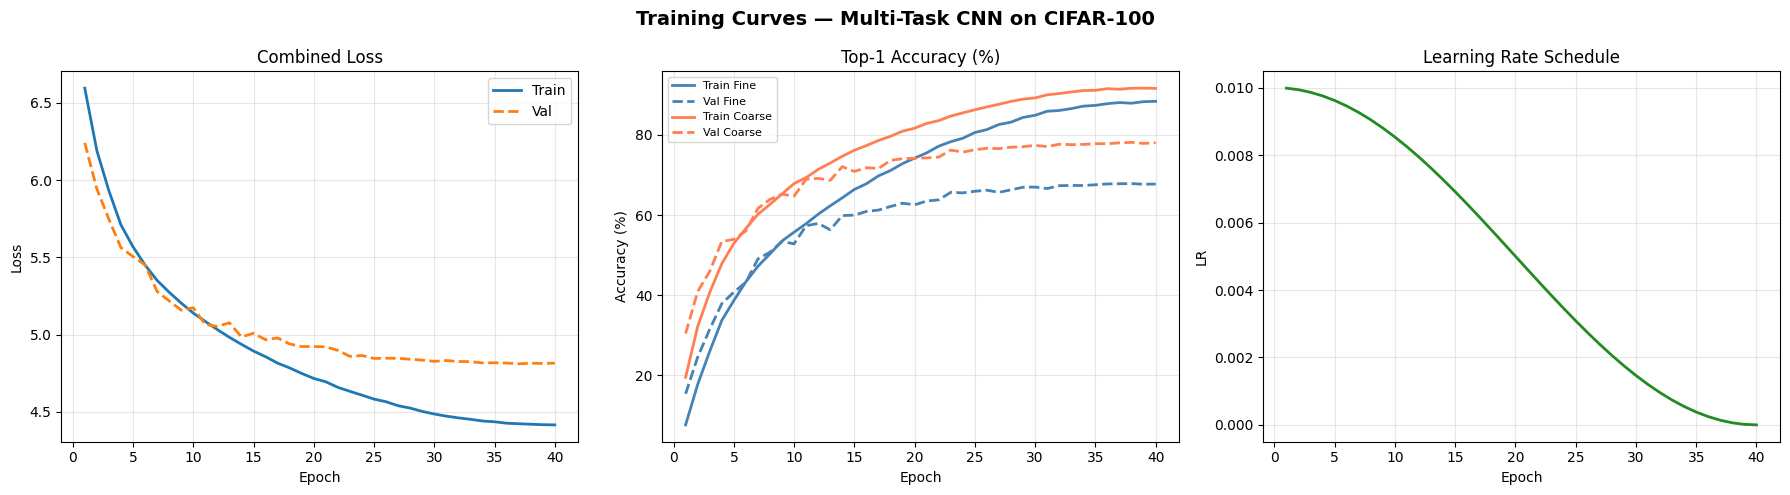

In [8]:
epochs = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training Curves — Multi-Task CNN on CIFAR-100', fontsize=14, fontweight='bold')

# ── Loss ─────────────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(epochs, history['train_loss'], label='Train', linewidth=2)
ax.plot(epochs, history['val_loss'],   label='Val',   linewidth=2, linestyle='--')
ax.set(title='Combined Loss', xlabel='Epoch', ylabel='Loss')
ax.legend()
ax.grid(alpha=0.3)

# ── Fine accuracy ─────────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(epochs, history['train_fine_acc'], label='Train Fine',   linewidth=2, color='steelblue')
ax.plot(epochs, history['val_fine_acc'],   label='Val Fine',     linewidth=2, color='steelblue', linestyle='--')
ax.plot(epochs, history['train_coarse_acc'], label='Train Coarse', linewidth=2, color='coral')
ax.plot(epochs, history['val_coarse_acc'],   label='Val Coarse',   linewidth=2, color='coral', linestyle='--')
ax.set(title='Top-1 Accuracy (%)', xlabel='Epoch', ylabel='Accuracy (%)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# ── Learning rate ─────────────────────────────────────────────────────────────
ax = axes[2]
ax.plot(epochs, history['lr'], color='forestgreen', linewidth=2)
ax.set(title='Learning Rate Schedule', xlabel='Epoch', ylabel='LR')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Load Best Model & Full Evaluation

In [9]:
# ── Load best checkpoint ──────────────────────────────────────────────────────
model.load_state_dict(torch.load('best_model.pth', map_location=DEVICE))
model.eval()

# ── Collect all predictions ───────────────────────────────────────────────────
all_fine_preds   = []
all_fine_labels  = []
all_coarse_preds = []
all_coarse_labels = []

# Also keep top-5 counts
fine_top5_correct = 0
n_total           = 0

with torch.no_grad():
    for imgs, fine_labels, coarse_labels in test_loader:
        imgs = imgs.to(DEVICE)
        fine_out, coarse_out = model(imgs)

        fine_pred   = fine_out.argmax(1).cpu()
        coarse_pred = coarse_out.argmax(1).cpu()

        all_fine_preds.extend(fine_pred.numpy())
        all_fine_labels.extend(fine_labels.numpy())
        all_coarse_preds.extend(coarse_pred.numpy())
        all_coarse_labels.extend(coarse_labels.numpy())

        # Top-5 fine
        top5 = fine_out.topk(5, dim=1).indices.cpu()
        for i, lbl in enumerate(fine_labels):
            if lbl in top5[i]:
                fine_top5_correct += 1
        n_total += imgs.size(0)

all_fine_preds    = np.array(all_fine_preds)
all_fine_labels   = np.array(all_fine_labels)
all_coarse_preds  = np.array(all_coarse_preds)
all_coarse_labels = np.array(all_coarse_labels)

# ── Summary metrics ───────────────────────────────────────────────────────────
fine_acc        = (all_fine_preds == all_fine_labels).mean() * 100
coarse_acc      = (all_coarse_preds == all_coarse_labels).mean() * 100
fine_top5_acc   = fine_top5_correct / n_total * 100

print('═' * 50)
print('     FINAL TEST-SET PERFORMANCE')
print('═' * 50)
print(f'  Fine   Top-1 Accuracy : {fine_acc:>7.2f}%')
print(f'  Fine   Top-5 Accuracy : {fine_top5_acc:>7.2f}%')
print(f'  Coarse Top-1 Accuracy : {coarse_acc:>7.2f}%')
print('═' * 50)

══════════════════════════════════════════════════
     FINAL TEST-SET PERFORMANCE
══════════════════════════════════════════════════
  Fine   Top-1 Accuracy :   68.00%
  Fine   Top-5 Accuracy :   89.49%
  Coarse Top-1 Accuracy :   77.62%
══════════════════════════════════════════════════


## 9. Per-Superclass (Coarse) Accuracy

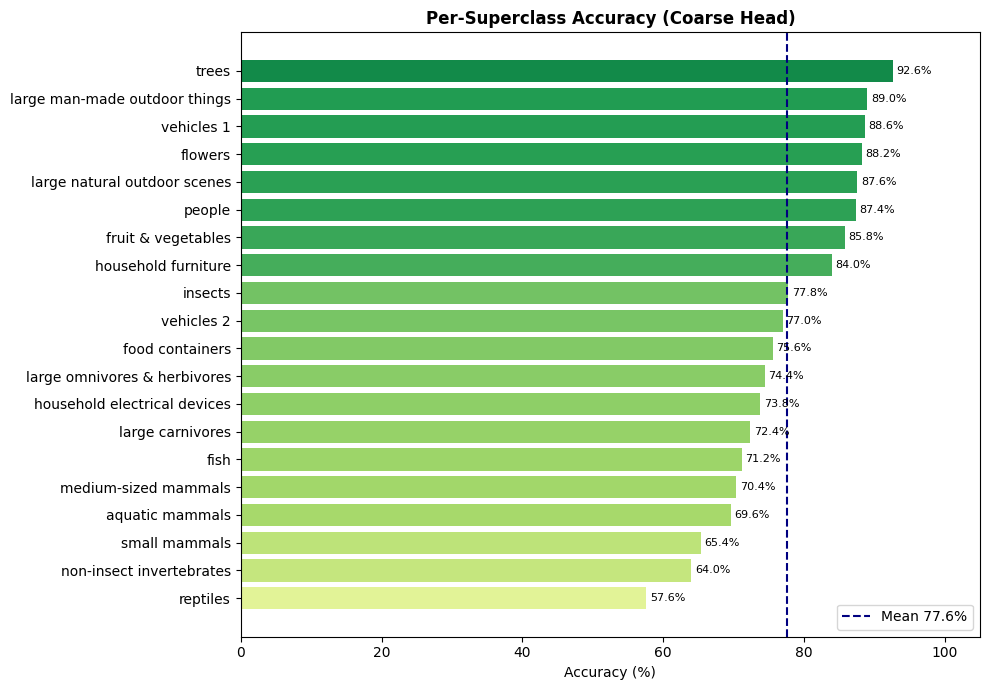

In [10]:
coarse_per_class = []
for c in range(NUM_COARSE_CLASSES):
    mask = all_coarse_labels == c
    acc  = (all_coarse_preds[mask] == all_coarse_labels[mask]).mean() * 100
    coarse_per_class.append(acc)

sorted_idx    = np.argsort(coarse_per_class)
sorted_labels = [COARSE_LABELS[i] for i in sorted_idx]
sorted_accs   = [coarse_per_class[i] for i in sorted_idx]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(sorted_labels, sorted_accs,
               color=plt.cm.RdYlGn(np.array(sorted_accs) / 100))
ax.set_xlabel('Accuracy (%)')
ax.set_title('Per-Superclass Accuracy (Coarse Head)', fontweight='bold')
ax.axvline(coarse_acc, color='navy', linestyle='--', linewidth=1.5,
           label=f'Mean {coarse_acc:.1f}%')
ax.legend()
for bar, acc in zip(bars, sorted_accs):
    ax.text(acc + 0.5, bar.get_y() + bar.get_height()/2,
            f'{acc:.1f}%', va='center', fontsize=8)
ax.set_xlim(0, 105)
plt.tight_layout()
plt.savefig('coarse_per_class_acc.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Confusion Matrix — Coarse Classes

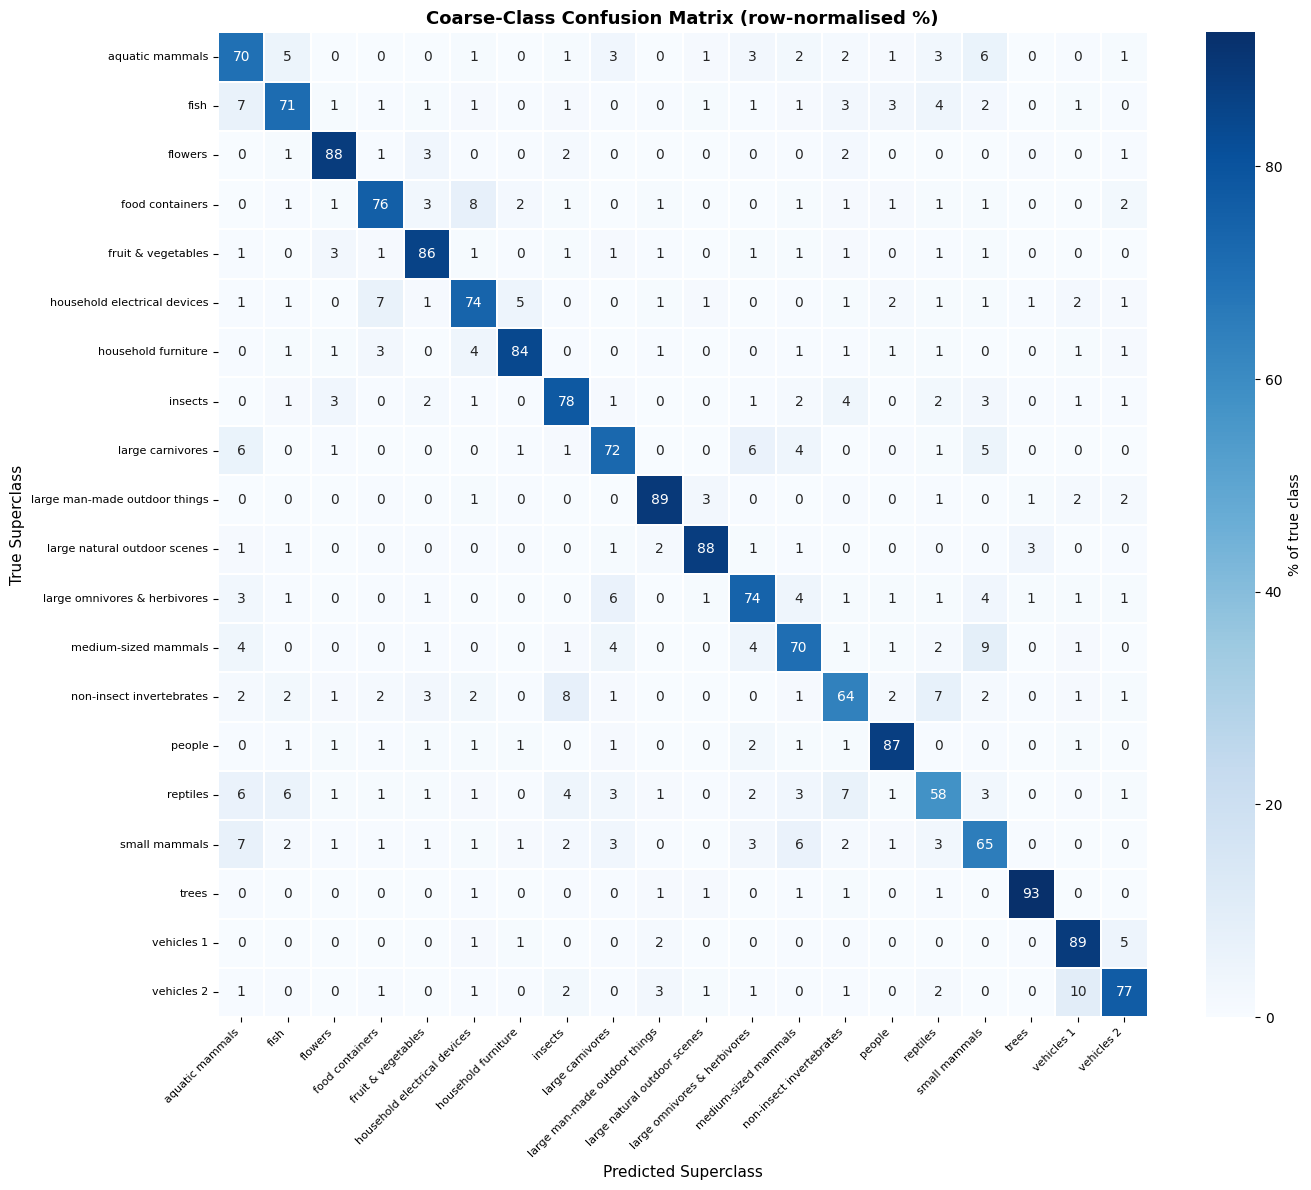

In [11]:
cm_coarse = confusion_matrix(all_coarse_labels, all_coarse_preds)

# Normalise to percentages per true class
cm_norm = cm_coarse.astype(float) / cm_coarse.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    cm_norm, annot=True, fmt='.0f', cmap='Blues',
    xticklabels=COARSE_LABELS, yticklabels=COARSE_LABELS,
    linewidths=0.3, ax=ax, cbar_kws={'label': '% of true class'}
)
ax.set_xlabel('Predicted Superclass', fontsize=11)
ax.set_ylabel('True Superclass', fontsize=11)
ax.set_title('Coarse-Class Confusion Matrix (row-normalised %)', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('coarse_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Confusion Matrix — Fine Classes (Top-20 most confused)

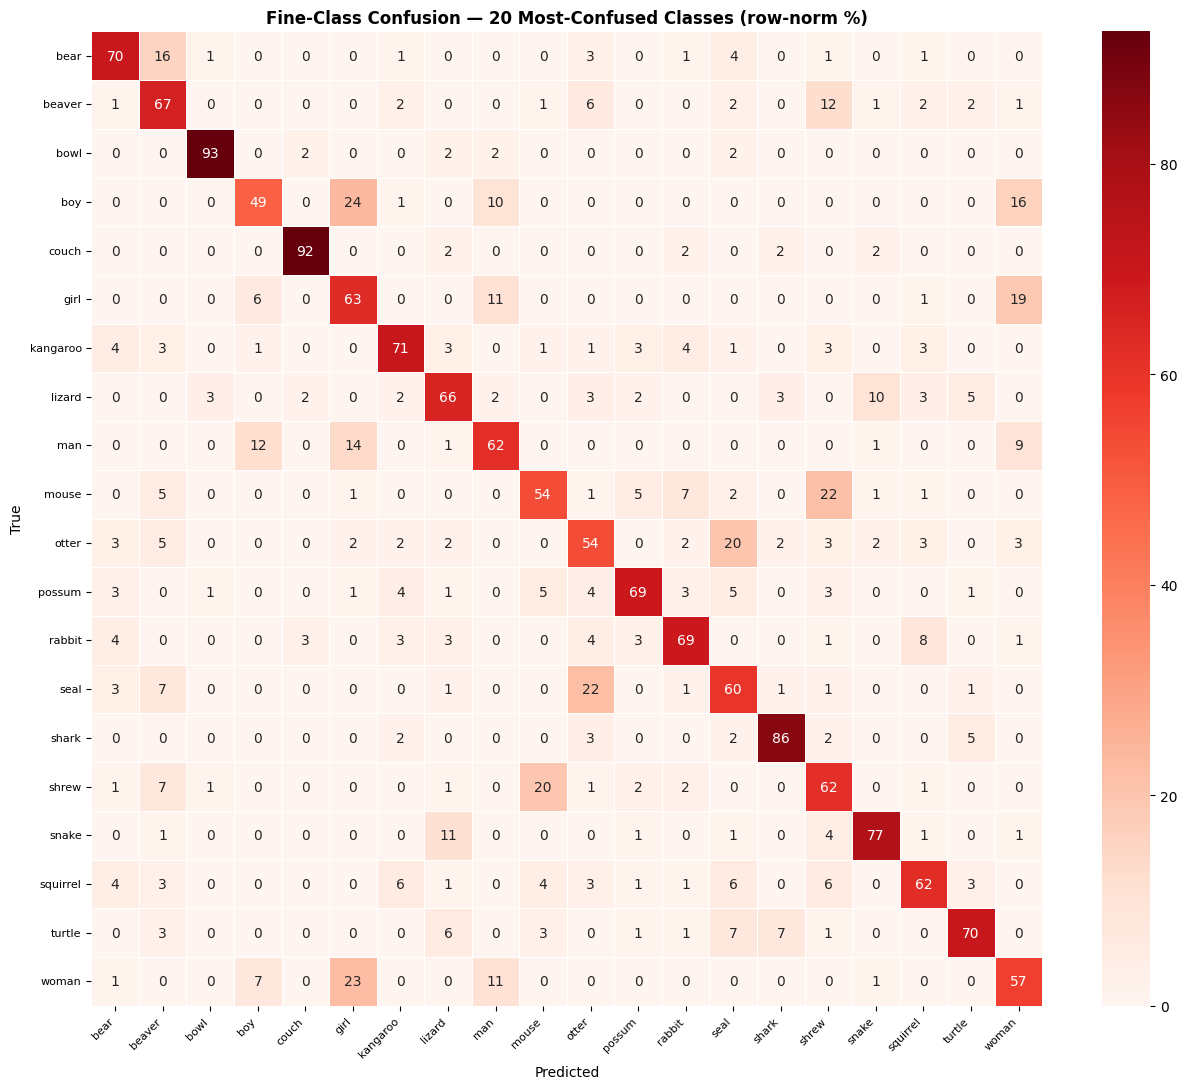

In [12]:
cm_fine = confusion_matrix(all_fine_labels, all_fine_preds)

# Find 20 classes with lowest diagonal accuracy
diag_acc    = cm_fine.diagonal() / cm_fine.sum(axis=1)
worst20_idx = np.argsort(diag_acc)[:20]
worst20_idx = np.sort(worst20_idx)

cm_sub  = cm_fine[np.ix_(worst20_idx, worst20_idx)]
cm_sub_norm = cm_sub.astype(float) / (cm_sub.sum(axis=1, keepdims=True) + 1e-8) * 100
sub_names   = [fine_names[i] for i in worst20_idx]

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(
    cm_sub_norm, annot=True, fmt='.0f', cmap='Reds',
    xticklabels=sub_names, yticklabels=sub_names,
    linewidths=0.4, ax=ax
)
ax.set_title('Fine-Class Confusion — 20 Most-Confused Classes (row-norm %)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted', fontsize=10)
ax.set_ylabel('True', fontsize=10)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('fine_confusion_worst20.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Per-Fine-Class Accuracy Distribution

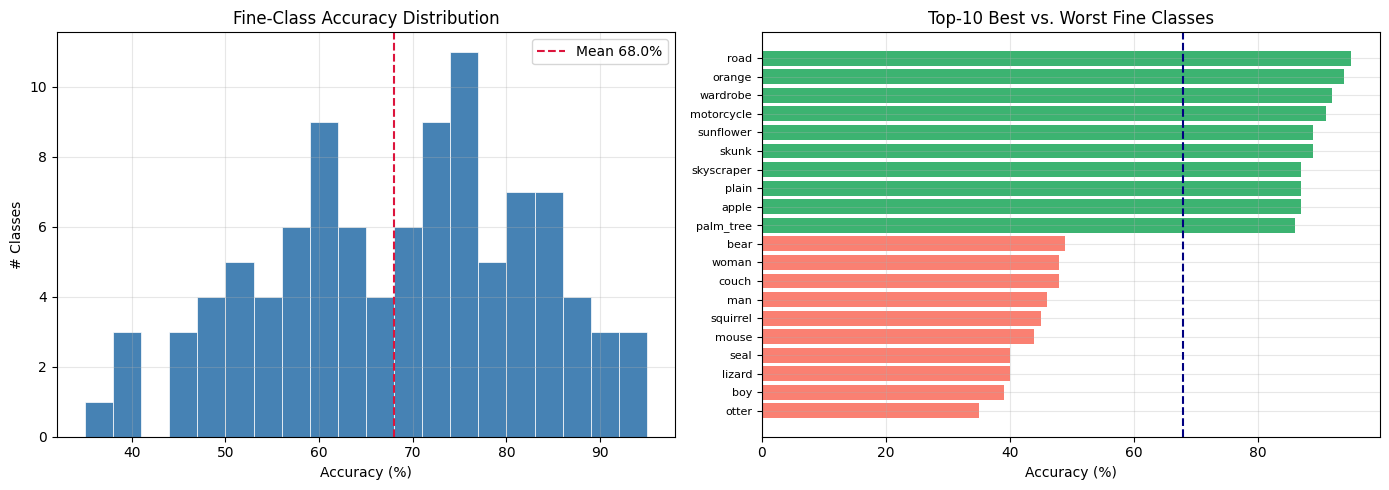

Fine class accuracy — Min: 35.0%  Max: 95.0%  Mean: 68.0%  Median: 69.5%


In [13]:
per_fine_acc = diag_acc * 100  # already computed above

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(per_fine_acc, bins=20, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].axvline(per_fine_acc.mean(), color='crimson', linestyle='--',
                label=f'Mean {per_fine_acc.mean():.1f}%')
axes[0].set(title='Fine-Class Accuracy Distribution',
             xlabel='Accuracy (%)', ylabel='# Classes')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Sorted bar (top-20 best and worst)
sort_idx = np.argsort(per_fine_acc)
worst10  = sort_idx[:10]
best10   = sort_idx[-10:]
show_idx = np.concatenate([worst10, best10])
colors   = ['salmon'] * 10 + ['mediumseagreen'] * 10
axes[1].barh([fine_names[i] for i in show_idx],
              per_fine_acc[show_idx], color=colors)
axes[1].axvline(per_fine_acc.mean(), color='navy', linestyle='--')
axes[1].set(title='Top-10 Best vs. Worst Fine Classes',
             xlabel='Accuracy (%)')
axes[1].tick_params(axis='y', labelsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fine_acc_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Fine class accuracy — Min: {per_fine_acc.min():.1f}%  '
      f'Max: {per_fine_acc.max():.1f}%  '
      f'Mean: {per_fine_acc.mean():.1f}%  '
      f'Median: {np.median(per_fine_acc):.1f}%')

## 13. Qualitative — Model Predictions on Test Images

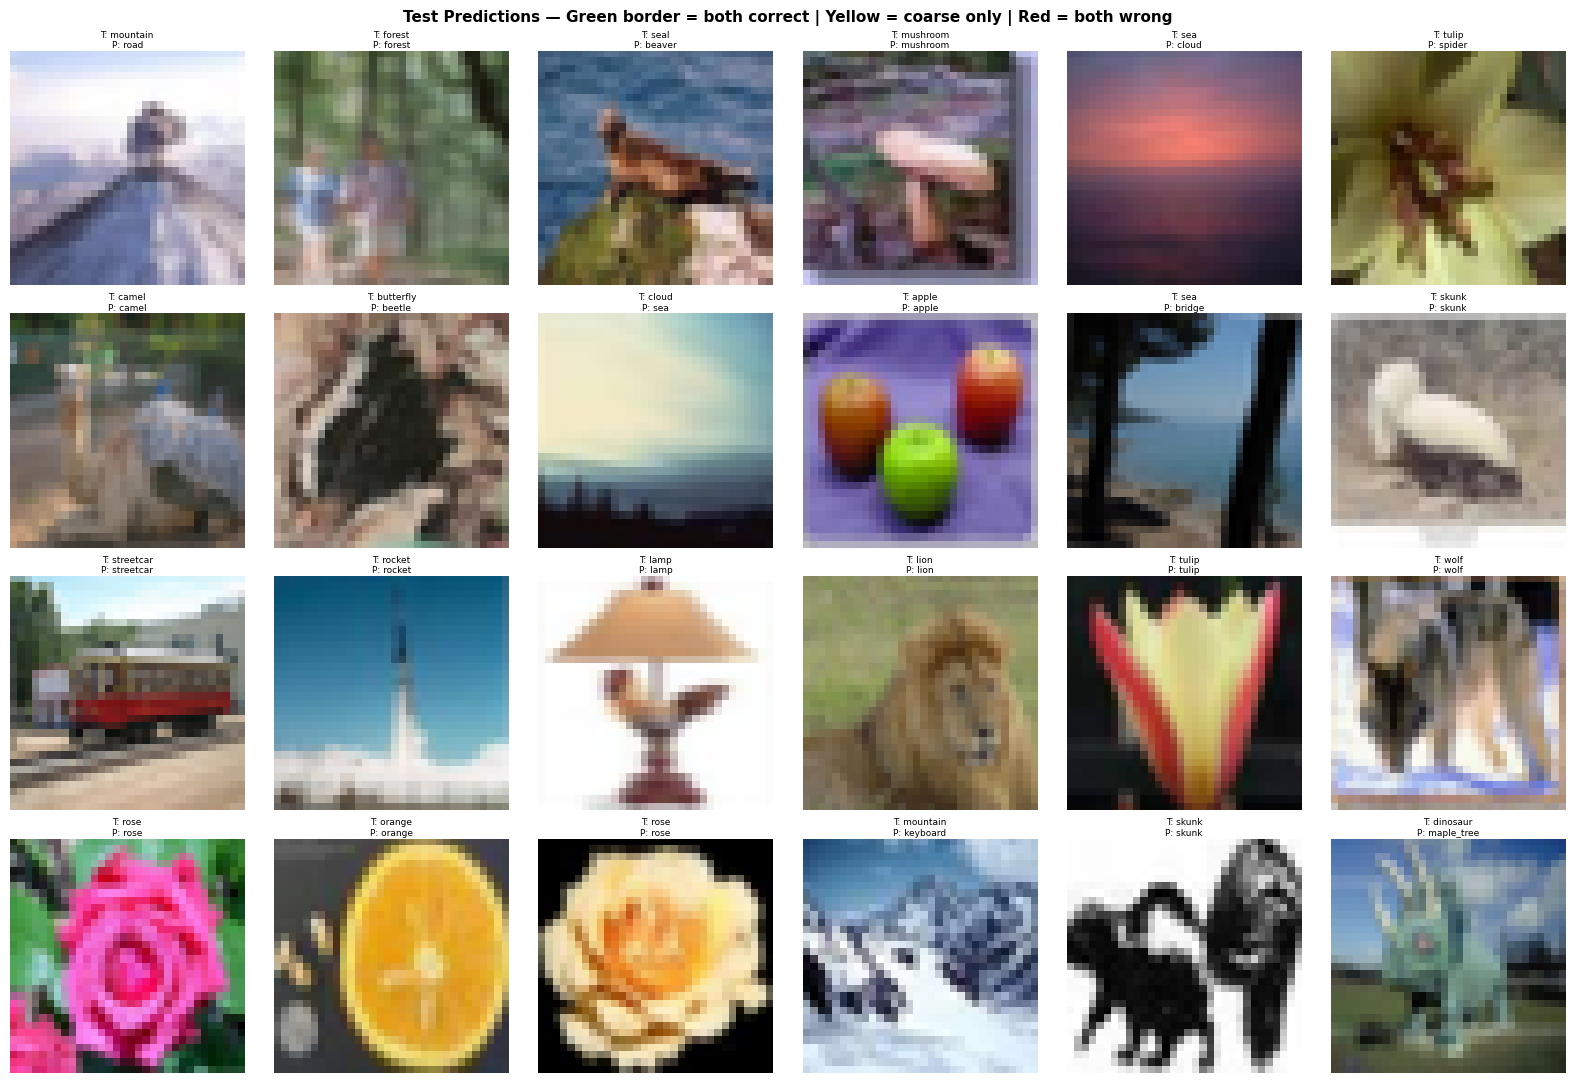

In [14]:
model.eval()

# Grab a batch from the test loader
imgs_b, fine_b, coarse_b = next(iter(test_loader))
imgs_b = imgs_b.to(DEVICE)

with torch.no_grad():
    fine_out_b, coarse_out_b = model(imgs_b)

fine_pred_b   = fine_out_b.argmax(1).cpu().numpy()
coarse_pred_b = coarse_out_b.argmax(1).cpu().numpy()

fig, axes = plt.subplots(4, 6, figsize=(16, 11))
fig.suptitle('Test Predictions — Green border = both correct | '
             'Yellow = coarse only | Red = both wrong',
             fontsize=11, fontweight='bold')

for i, ax in enumerate(axes.flat):
    img  = unnorm(imgs_b[i].cpu())
    ft   = fine_b[i].item()
    ct   = coarse_b[i].item()
    fp   = fine_pred_b[i]
    cp   = coarse_pred_b[i]

    fine_ok   = (ft == fp)
    coarse_ok = (ct == cp)

    if fine_ok and coarse_ok:
        border_color = 'limegreen'
    elif coarse_ok:
        border_color = 'gold'
    else:
        border_color = 'tomato'

    ax.imshow(img)
    for spine in ax.spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(3)

    ax.set_title(
        f'T: {fine_names[ft]}\nP: {fine_names[fp]}',
        fontsize=6.5, color='black', pad=2
    )
    ax.axis('off')

plt.tight_layout()
plt.savefig('qualitative_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. Classification Report (Coarse Classes)

In [15]:
report = classification_report(
    all_coarse_labels, all_coarse_preds,
    target_names=COARSE_LABELS, digits=3
)
print('Coarse-Class Classification Report')
print('=' * 80)
print(report)

Coarse-Class Classification Report
                               precision    recall  f1-score   support

              aquatic mammals      0.642     0.696     0.668       500
                         fish      0.757     0.712     0.734       500
                      flowers      0.865     0.882     0.873       500
              food containers      0.801     0.756     0.778       500
           fruit & vegetables      0.831     0.858     0.844       500
 household electrical devices      0.738     0.738     0.738       500
          household furniture      0.852     0.840     0.846       500
                      insects      0.745     0.778     0.761       500
             large carnivores      0.720     0.724     0.722       500
large man-made outdoor things      0.869     0.890     0.879       500
 large natural outdoor scenes      0.888     0.876     0.882       500
 large omnivores & herbivores      0.744     0.744     0.744       500
         medium-sized mammals      0.698 

## 15. Results Summary

In [16]:
print('╔══════════════════════════════════════════════════════╗')
print('║         MULTI-TASK CNN — FINAL RESULTS SUMMARY       ║')
print('╠══════════════════════════════════════════════════════╣')
print(f'║  Dataset           : CIFAR-100 (no augmentation)     ║')
print(f'║  Architecture      : Custom 3-block CNN + 2 heads    ║')
print(f'║  Parameters        : {trainable_params:>10,}                   ║')
print(f'║  Training epochs   : {NUM_EPOCHS:<33} ║')
print(f'║  Batch size        : {BATCH_SIZE:<33} ║')
print('╠══════════════════════════════════════════════════════╣')
print(f'║  Fine   Top-1 Acc  : {fine_acc:>7.2f}%                       ║')
print(f'║  Fine   Top-5 Acc  : {fine_top5_acc:>7.2f}%                       ║')
print(f'║  Coarse Top-1 Acc  : {coarse_acc:>7.2f}%                       ║')
print(f'║  Best epoch        : {best_epoch:<33} ║')
print('╚══════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════╗
║         MULTI-TASK CNN — FINAL RESULTS SUMMARY       ║
╠══════════════════════════════════════════════════════╣
║  Dataset           : CIFAR-100 (no augmentation)     ║
║  Architecture      : Custom 3-block CNN + 2 heads    ║
║  Parameters        :  2,748,600                   ║
║  Training epochs   : 40                                ║
║  Batch size        : 128                               ║
╠══════════════════════════════════════════════════════╣
║  Fine   Top-1 Acc  :   68.00%                       ║
║  Fine   Top-5 Acc  :   89.49%                       ║
║  Coarse Top-1 Acc  :   77.62%                       ║
║  Best epoch        : 38                                ║
╚══════════════════════════════════════════════════════╝


---
## Appendix — Architecture Notes

### Why Multi-Task Learning?
The fine and coarse labels are hierarchically related — every fine class belongs to exactly one coarse superclass. Jointly learning both tasks forces the shared backbone to build representations that respect this hierarchy, acting as an inductive bias that can improve both tasks compared to training them independently.

### Loss Weighting
```
L_total = 1.0 × L_fine + 0.5 × L_coarse
```
The coarse task is weighted at 0.5 because it's an auxiliary signal; the primary objective is fine classification. Tuning this ratio is a valid extension.

### Potential Improvements
| Technique | Expected gain |
|-----------|---------------|
| Data augmentation (RandAugment, Cutout) | +5–10% fine acc |
| Residual / skip connections | +2–4% |
| Label smoothing | +1–2% |
| Hierarchical softmax | architectural improvement |
| Larger backbone (ResNet-50) | +10–15% |